# Iris Flower Classification using Machine Learning

## CodeAlpha Data Science Internship - Task 1

Author: Vishwashikha Patel

# Iris Flower Classification using Machine Learning

## CodeAlpha Data Science Internship - Task 1

## Objective

The objective of this project is to classify Iris flowers into three species:
- Iris Setosa
- Iris Versicolor
- Iris Virginica
using machine learning techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Dataset Description

The Iris dataset contains 150 samples and 4 features.

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (150, 4)
Target Shape: (150,)


## Data Preparation

Converting the dataset into a Pandas DataFrame for easier analysis and visualization.

In [3]:
df = pd.DataFrame(X, columns=iris.feature_names)

df["species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Exploratory Data Analysis

Understanding the structure and statistical properties of the dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
df["species"].value_counts()

species
0    50
1    50
2    50
Name: count, dtype: int64

## Data Visualization

Visualizing relationships among features to understand patterns in the data.

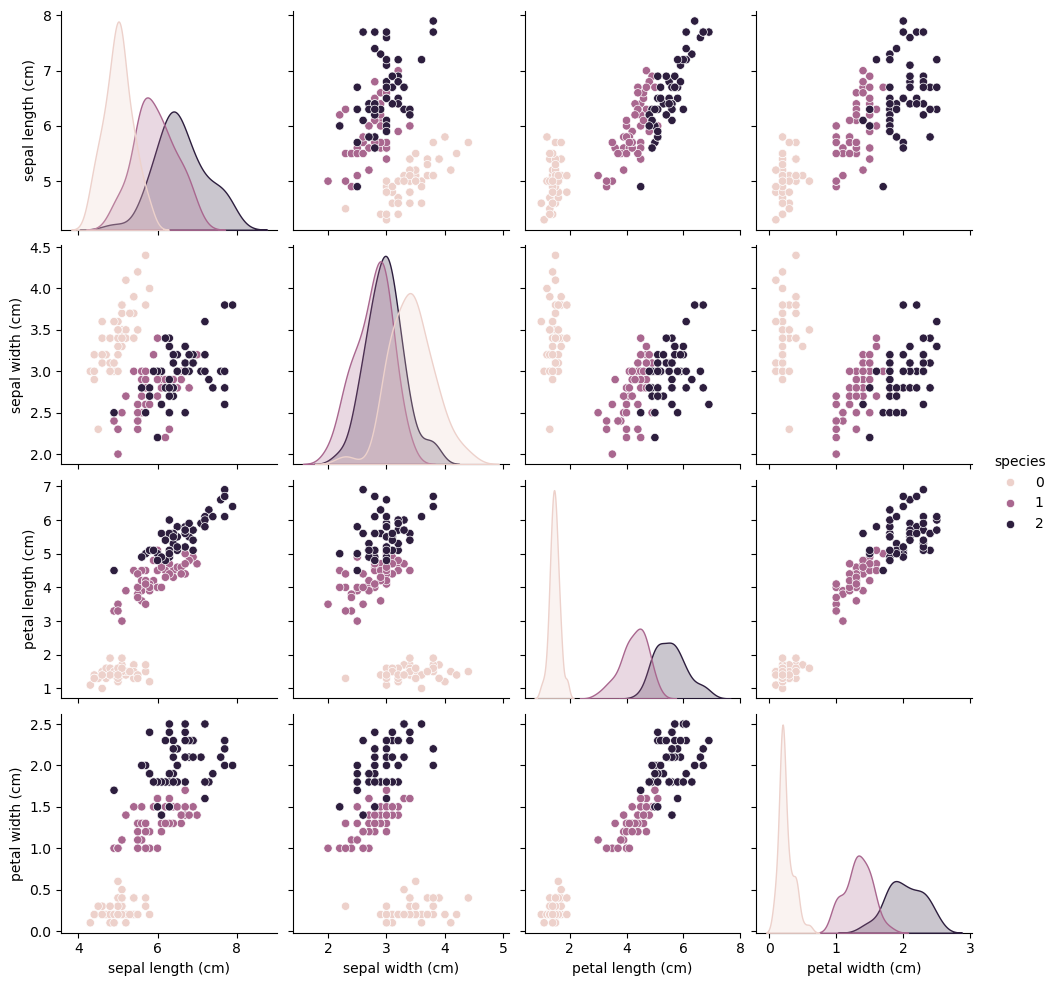

In [7]:
sns.pairplot(df, hue="species")
plt.show()

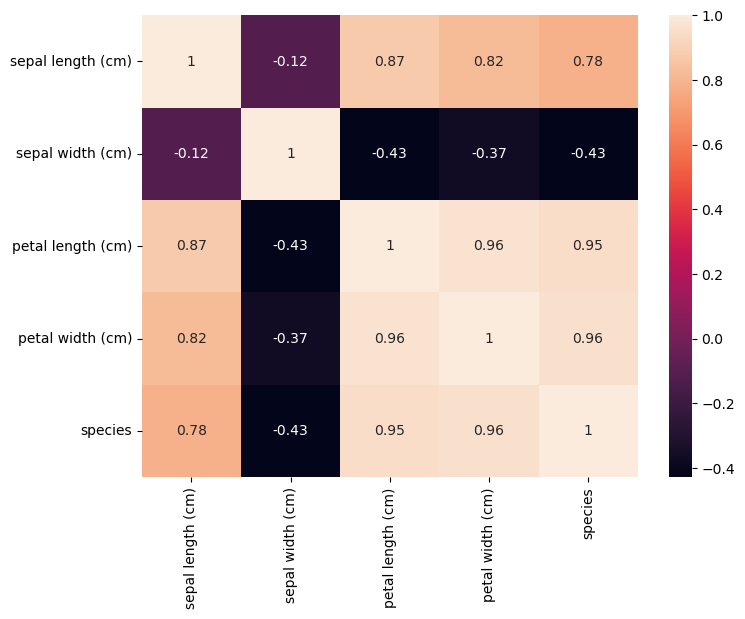

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

## Splitting Dataset

The dataset is divided into training and testing sets for model evaluation.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


## Model Training

Training a Random Forest Classifier on the Iris dataset.

In [10]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Prediction

Using the trained model to predict flower species.

In [11]:
y_pred = model.predict(X_test)

## Model Evaluation

Evaluating the model using accuracy score, classification report, and confusion matrix.

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



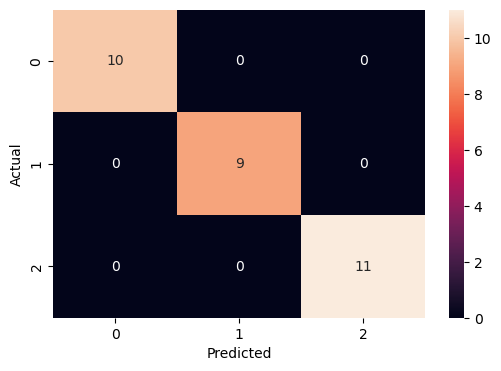

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Testing with New Data

Predicting the species of a new flower using custom measurements.

In [15]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Species:", iris.target_names[prediction][0])

Predicted Species: setosa


## Saving the Model

Saving the trained machine learning model for future use.

In [16]:
import joblib

joblib.dump(model, "iris_model.pkl")

['iris_model.pkl']

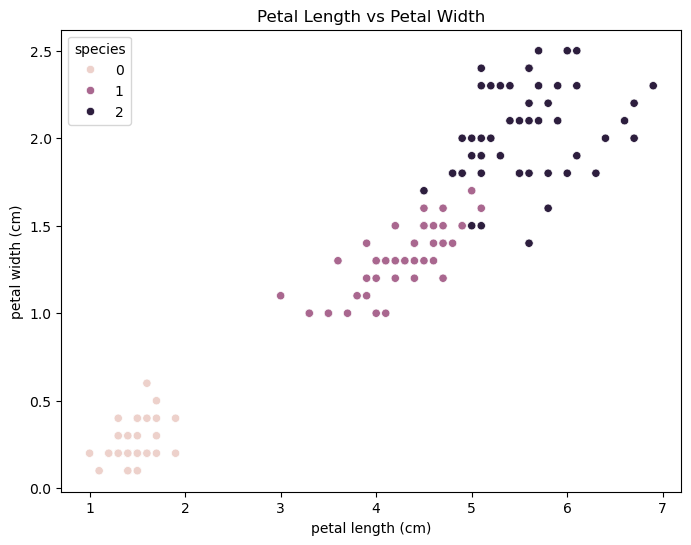

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    data=df
)
plt.title("Petal Length vs Petal Width")
plt.show()

## Conclusion

The Random Forest Classifier successfully classified Iris flower species with high accuracy.

This project demonstrates the use of supervised machine learning techniques for classification problems and provides a foundation for more advanced machine learning applications.